# Quantile-mapping baseline: distribution-level downscaling

This notebook presents the results only. Every field, table and metric is read
from the caches written by `scripts/run_quantile_mapping.py`; the analysis code
lives in `src/predictors.py`, `src/quantile_windows.py`, `src/qm_metrics.py` and
`src/qm_visualization.py`.

**Contents**

| Section | Content |
|---|---|
| 1 | Method: why distributions, and the three hyper-parameters |
| 2 | The five predictor fields |
| 3 | One slice in detail: 1999-Q2, bilinear, P50 |
| 4 | All five percentiles in the same slice |
| 5 | Across predictors: the leaderboard |
| 6 | Across window lengths |
| 7 | Where the predictors break down |
| 8 | Summary |

To explore combinations beyond the ones shown here, use the dashboard:

```bash
python3 -m streamlit run dashboards/qm_dashboard.py
```

## 0. Environment setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src import data_io as dio
from src import qm_metrics as qmm
from src import qm_visualization as qviz
from src import quantile_windows as qw
from src import spatial_ops as sops
from src.predictors import PREDICTOR_NAMES, load_cached_predictors

DATA_DIR = ROOT / "data"
CACHE_DIR = DATA_DIR / "cache"
QM_DIR = CACHE_DIR / "qm"
PLOT_DIR = ROOT / "plots"
PLOT_DIR.mkdir(exist_ok=True)

REGION = dict(south=24, north=38, west=30, east=38)

# The slice shown in Sections 3 and 4.
FOCUS_SCHEME = "quarter"
FOCUS_WINDOW = "1999-Q2"
FOCUS_PREDICTOR = "bilinear"
FOCUS_Q = 50

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

missing = [p for p in PREDICTOR_NAMES
           for s in qw.SCHEMES
           if not qmm.pct_table_path(QM_DIR, p, s).exists()]
if missing:
    raise FileNotFoundError(
        "Missing percentile tables. Run: python3 scripts/run_quantile_mapping.py"
    )

metrics    = pd.read_parquet(QM_DIR / qmm.METRIC_FILES["metrics"])
pixel_bias = pd.read_parquet(QM_DIR / qmm.METRIC_FILES["pixel"])
window_bias = pd.read_parquet(QM_DIR / qmm.METRIC_FILES["window"])
elev_bias  = pd.read_parquet(QM_DIR / qmm.METRIC_FILES["elev"])
sea_bias   = pd.read_parquet(QM_DIR / qmm.METRIC_FILES["sea"])
lapse      = pd.read_parquet(QM_DIR / "lapse_rates.parquet")
static     = pd.read_parquet(QM_DIR / "static_pixels.parquet")

print(f"metrics table: {len(metrics)} combinations "
      f"({metrics.predictor.nunique()} predictors x "
      f"{metrics.scheme.nunique()} windows x "
      f"{metrics.percentile.nunique()} percentiles)")
print(f"land pixels:   {len(static):,}")

metrics table: 100 combinations (5 predictors x 4 windows x 5 percentiles)
land pixels:   7,683


## 1. Method

### Why distributions and not days

The baseline in `02_models.ipynb` regressed observed daily temperature on
coarse daily temperature. Ronit's note *On the baseline model* (16 Aug 2026)
sets out the problem with that frame: there is no real correspondence between a
date in the CMIP6 record and the same date in the observations, so a
Perfect-Prognosis regression cannot be fitted on daily GCM output. The Model
Output Statistics route — empirical quantile mapping (EQM, Déqué 2007) — avoids
the issue by comparing distributions instead.

This notebook builds the diagnostic that EQM needs. It does not fit or apply a
correction. For each fine pixel and each window it compares the percentiles of
the observation with the percentiles of a coarse-derived predictor, and asks
whether the difference follows a pattern.

Following Iturbide et al. (2019), the two fields are brought to the same
resolution before the quantiles are compared. The predictors below are the
five ways of doing that regridding.

### The three hyper-parameters

Notation: Y is the observed ERA5-Land percentile at a pixel and window, X is
the predictor percentile at the same pixel and window, and

$$\mathrm{bias} = X - Y$$

so a positive bias means the predictor is too warm. This is the project
convention (model minus observation).

In [2]:
windows_summary = []
_dates = pd.date_range("1990-01-01", "1999-12-31", freq="D")
_dates = _dates[~((_dates.month == 2) & (_dates.day == 29))]
_dates = [d.strftime("%Y-%m-%d") for d in _dates]

for scheme in qw.SCHEMES:
    w, _ = qw.make_windows(_dates, scheme)
    windows_summary.append({
        "Window": qviz.SCHEME_LABELS[scheme],
        "Windows": len(w),
        "Days per window": (f"{w.n_days.min()}" if w.n_days.min() == w.n_days.max()
                            else f"{w.n_days.min()}–{w.n_days.max()}"),
        "First": w.label.iloc[0],
        "Last": w.label.iloc[-1],
    })

print("Hyper-parameter 1 — distribution window (non-overlapping, calendar aligned)")
display(pd.DataFrame(windows_summary).set_index("Window"))

print("\nHyper-parameter 2 — percentile")
print("  " + ", ".join(f"P{q}" for q in qw.PERCENTILES))

print("\nHyper-parameter 3 — predictor")
display(pd.DataFrame([
    {"Predictor": qviz.PREDICTOR_LABELS["knn4"],
     "Definition": "mean TAS of the 4 nearest CMIP6 cell centres"},
    {"Predictor": qviz.PREDICTOR_LABELS["knn9"],
     "Definition": "mean TAS of the 9 nearest centres (the 3x3 block)"},
    {"Predictor": qviz.PREDICTOR_LABELS["bilinear"],
     "Definition": "bilinear remapping of TAS to the 0.1° grid"},
    {"Predictor": qviz.PREDICTOR_LABELS["trilinear_fit"],
     "Definition": "bilinear + Γ·Δz, Γ fitted per season on 1990–1999"},
    {"Predictor": qviz.PREDICTOR_LABELS["trilinear_fixed"],
     "Definition": "bilinear + Γ·Δz, Γ = −6.5 °C/km"},
]).set_index("Predictor"))

Hyper-parameter 1 — distribution window (non-overlapping, calendar aligned)


,Windows,Days per window,First,Last
Window,,,,
14 days,260,14–15,1990-B01,1999-B26
1 month,120,28–31,1990-01,1999-12
1 quarter,40,90–92,1990-Q1,1999-Q4
1 year,10,365,1990,1999



Hyper-parameter 2 — percentile
  P5, P25, P50, P75, P90

Hyper-parameter 3 — predictor


,Definition
Predictor,
"k-NN, k=4",mean TAS of the 4 nearest CMIP6 cell centres
"k-NN, k=9",mean TAS of the 9 nearest centres (the 3x3 block)
Bilinear,bilinear remapping of TAS to the 0.1° grid
Trilinear (fitted Γ),"bilinear + Γ·Δz, Γ fitted per season on 1990–1999"
Trilinear (−6.5 K/km),"bilinear + Γ·Δz, Γ = −6.5 °C/km"


The k-nearest-neighbour predictors follow the analog work of Dorita and Anton,
who found that the mean TAS of a 3×3 block of coarse cells around the target
was an adequate predictor. Bedia et al. (2020) report the same for
precipitation: local predictors carry most of the information.

The two trilinear predictors add a terrain term. Δz is the sub-grid terrain the
coarse model cannot see — the fine ETOPO elevation minus the CMIP6 cell-mean
orography brought back to the fine grid by the same bilinear operator. Γ is
either fitted or fixed at the environmental lapse rate.

In [3]:
print("Fitted lapse rates Γ — OLS of (observed − bilinear) on Δz, land pixels only")
display(
    lapse.assign(**{"Γ (°C/km)": lapse.gamma_per_km.round(2)})
         .rename(columns={"season": "Season", "n": "n (pixel-days)"})
         [["Season", "Γ (°C/km)", "n (pixel-days)"]]
         .style.format({"n (pixel-days)": "{:,.0f}"}).hide(axis="index")
)

print(f"\nΔz range over land: {static.dz.min():.0f} to {static.dz.max():.0f} m "
      f"(SD {static.dz.std():.0f} m)")
print(f"Elevation range over land: {static.elevation.min():.0f} to "
      f"{static.elevation.max():.0f} m")

Fitted lapse rates Γ — OLS of (observed − bilinear) on Δz, land pixels only


Season,Γ (°C/km),n (pixel-days)
all,-3.320000,"28,042,950"
DJF,-3.380000,"6,914,700"
MAM,-3.080000,"7,068,360"
JJA,-3.580000,"7,068,360"
SON,-2.500000,"6,991,530"



Δz range over land: -1171 to 2619 m (SD 341 m)
Elevation range over land: -504 to 3200 m


The fitted Γ is around −3 °C km⁻¹ in every season, roughly half the free-air
environmental rate of −6.5 °C km⁻¹. Two factors may contribute. The regression
target is the bilinear residual, which mixes the terrain signal with other
biases, so the terrain term absorbs only part of the total. Near-surface lapse
rates over land are also generally shallower than free-air rates, because the
surface energy balance couples the air to the ground. The seasonal spread is
small: SON is the weakest at −2.5 °C km⁻¹ and JJA the strongest at
−3.6 °C km⁻¹.

*A caveat on short windows.* A 14-day window holds only 14 values, so its P5 and
P90 are estimated from roughly the first and last value of the sample. Window
length trades sampling noise against temporal resolution, and Section 6 has to
be read with that in mind.

## 2. The five predictor fields

Each predictor is a full field on the ERA5-Land 0.1° grid, so Y and X live at
the same pixel. The figure below shows the observed decadal mean and, for each
predictor, its difference from that mean.

In [4]:
era5_files = sorted(DATA_DIR.glob("t2m_ERA5land_daily_*.nc"))
cmip_file  = next(DATA_DIR.glob("tas_day_*.nc"))

era5_ds = dio.load_era5_land(era5_files, region=REGION)
cmip_ds = dio.load_cmip6(cmip_file, region=REGION, pad_lat=1.0, pad_lon=1.5)
era5_ds, cmip_ds, shared_dates = dio.align_calendars(era5_ds, cmip_ds)

era5_temp = dio.to_celsius(era5_ds["t2m"])
era5_lats = era5_temp.latitude.values
era5_lons = era5_temp.longitude.values
cmip_lats = cmip_ds["lat"].values
cmip_lons = cmip_ds["lon"].values

land_mask_2d = sops.compute_land_mask(era5_temp)
era5_clim = era5_temp.mean(dim="time", skipna=True).values
era5_clim = np.where(land_mask_2d, era5_clim, np.nan)

fields = load_cached_predictors(CACHE_DIR)
clim_fields = {}
for name in PREDICTOR_NAMES:
    arr = fields[name].mean(dim="time").values
    clim_fields[name] = np.where(land_mask_2d, arr, np.nan)

print(f"Loaded {len(fields)} predictor fields, "
      f"shape {tuple(fields['bilinear'].shape)}")

/opt/homebrew/lib/python3.10/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Loaded 5 predictor fields, shape (3650, 141, 81)


/Users/shirke/Desktop/Thesis/src/qm_visualization.py:878: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb0.ax.set_yticklabels(


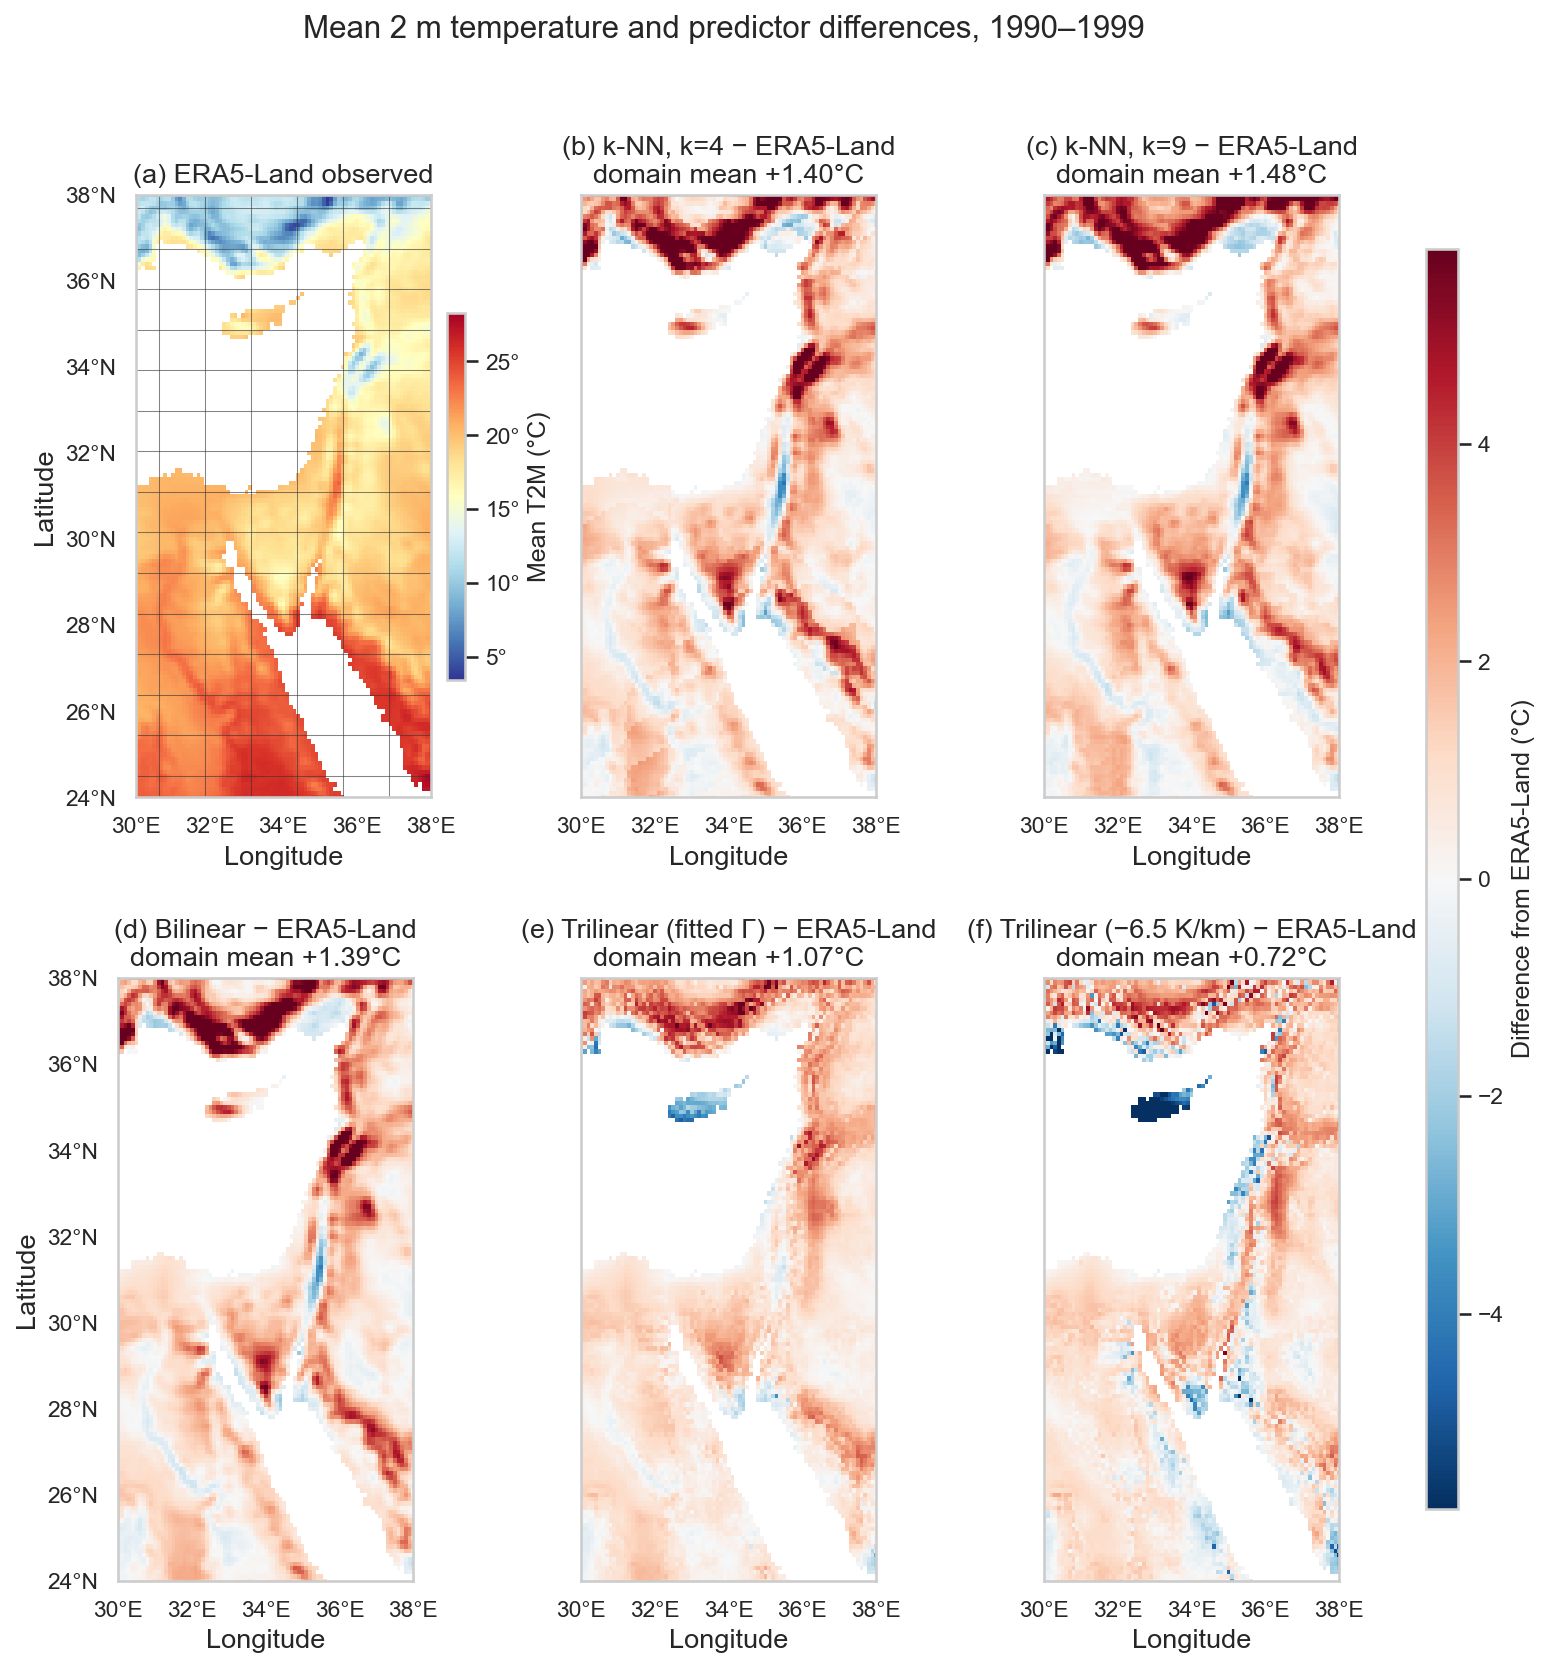

In [5]:
fig = qviz.plot_predictor_climatology_comparison(
    clim_fields, era5_clim, era5_lats, era5_lons,
    region=REGION, coarse_lats=cmip_lats, coarse_lons=cmip_lons,
    suptitle="Mean 2 m temperature and predictor differences, 1990–1999",
    save_path=PLOT_DIR / "fig_q01_predictor_climatology.png",
)
plt.show()

**Fig. 1.** Decadal mean 2 m temperature and predictor differences, 1990–1999.
Panel (a): ERA5-Land observed mean, with CMIP6 cell boundaries overlaid.
Panels (b)–(f): each predictor's decadal mean minus the ERA5-Land mean, on a
shared diverging scale. Positive (red) means the predictor is too warm. Data:
ERA5-Land daily 2 m temperature at 0.1° and CMIP6 CESM2-WACCM historical TAS at
~1°, land pixels of the EMME domain 24–38°N, 30–38°E.

In [6]:
rows = []
for name in PREDICTOR_NAMES:
    d = clim_fields[name] - era5_clim
    rows.append({
        "Predictor": qviz.PREDICTOR_LABELS[name],
        "Mean": np.nanmean(d), "Std Dev": np.nanstd(d),
        "Median": np.nanmedian(d),
        "P25": np.nanpercentile(d, 25), "P75": np.nanpercentile(d, 75),
        "Min": np.nanmin(d), "Max": np.nanmax(d),
    })
print("Decadal-mean difference from ERA5-Land, per land pixel (°C)")
display(pd.DataFrame(rows).set_index("Predictor").round(2))

Decadal-mean difference from ERA5-Land, per land pixel (°C)


,Mean,Std Dev,Median,P25,P75,Min,Max
Predictor,,,,,,,
"k-NN, k=4",1.40,1.68,1.05,0.38,2.01,-4.25,10.69
"k-NN, k=9",1.48,1.83,1.16,0.27,2.20,-4.10,11.62
Bilinear,1.39,1.60,1.09,0.40,1.97,-4.09,10.28
Trilinear (fitted Γ),1.07,1.13,0.90,0.43,1.56,-4.76,7.51
Trilinear (−6.5 K/km),0.72,1.56,0.83,0.24,1.39,-12.38,6.71


**Table 1.** Distribution over land pixels of the decadal-mean difference
between each predictor and ERA5-Land (°C). Positive values indicate a warm
predictor. Data: 1990–1999, EMME domain.

## 3. One slice in detail: 1999-Q2, bilinear, P50

All 100 combinations were computed. This section shows one of them so the
structure of the comparison is visible: the median of the April–June 1999
distribution, at every land pixel, bilinear predictor.

In [7]:
focus = qmm.slice_percentile(
    qmm.load_pct_table(QM_DIR, FOCUS_PREDICTOR, FOCUS_SCHEME),
    FOCUS_Q,
)
focus = focus[focus.window_label.astype(str) == FOCUS_WINDOW]

print(f"{FOCUS_WINDOW}: {focus.n_days.iloc[0]} days, {len(focus):,} land pixels")
print(f"observed P{FOCUS_Q}:  mean {focus.y.mean():.1f} ± {focus.y.std():.1f} °C   "
      f"range {focus.y.min():.1f} to {focus.y.max():.1f} °C")
print(f"predictor P{FOCUS_Q}: mean {focus.x.mean():.1f} ± {focus.x.std():.1f} °C   "
      f"range {focus.x.min():.1f} to {focus.x.max():.1f} °C")
print(f"bias:          mean {focus.bias.mean():+.2f} ± {focus.bias.std():.2f} °C   "
      f"median {focus.bias.median():+.2f} °C")

1999-Q2: 91 days, 7,683 land pixels
observed P50:  mean 24.0 ± 4.0 °C   range 7.5 to 33.6 °C
predictor P50: mean 23.7 ± 4.3 °C   range 14.3 to 31.3 °C
bias:          mean -0.30 ± 1.76 °C   median -0.32 °C


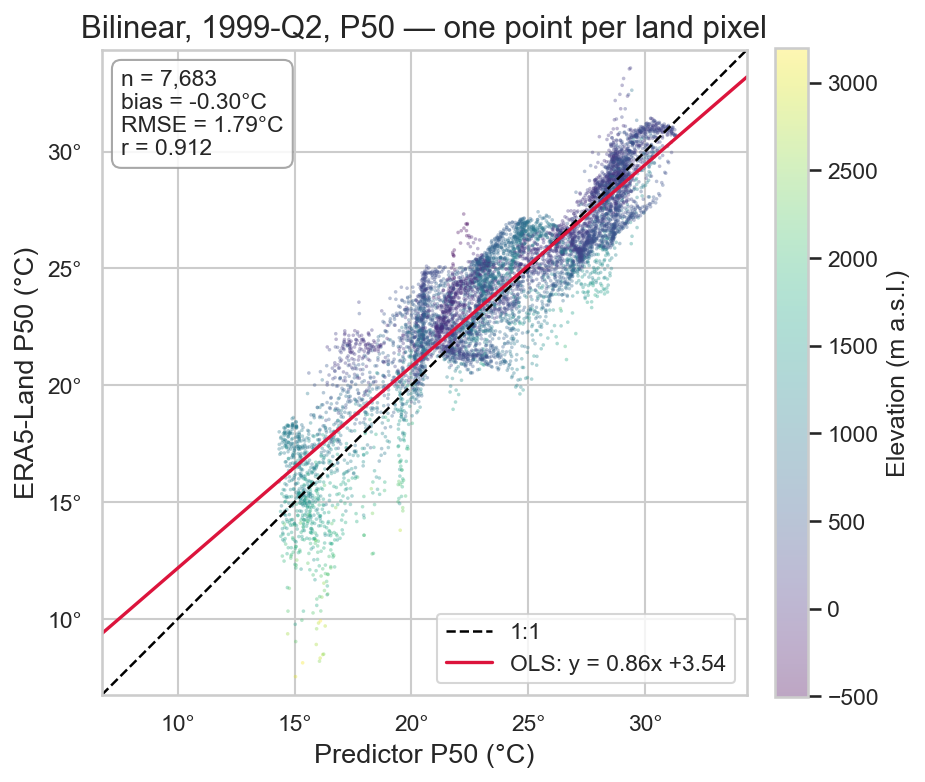

In [8]:
fig = qviz.plot_quantile_scatter(
    focus, q=FOCUS_Q, colour_by="elevation",
    title=(f"{qviz.PREDICTOR_LABELS[FOCUS_PREDICTOR]}, {FOCUS_WINDOW}, "
           f"P{FOCUS_Q} — one point per land pixel"),
    save_path=PLOT_DIR / "fig_q02_focus_scatter.png",
)
plt.show()

**Fig. 2.** Predictor median against observed median for the second quarter of
1999. Each point is one ERA5-Land land pixel (n ≈ 7,700), coloured by terrain
elevation. The dashed line is 1:1; the red line is the ordinary least squares
fit of observed on predictor. Data: ERA5-Land 2 m temperature and bilinearly
regridded CMIP6 CESM2-WACCM TAS, April–June 1999, EMME domain.

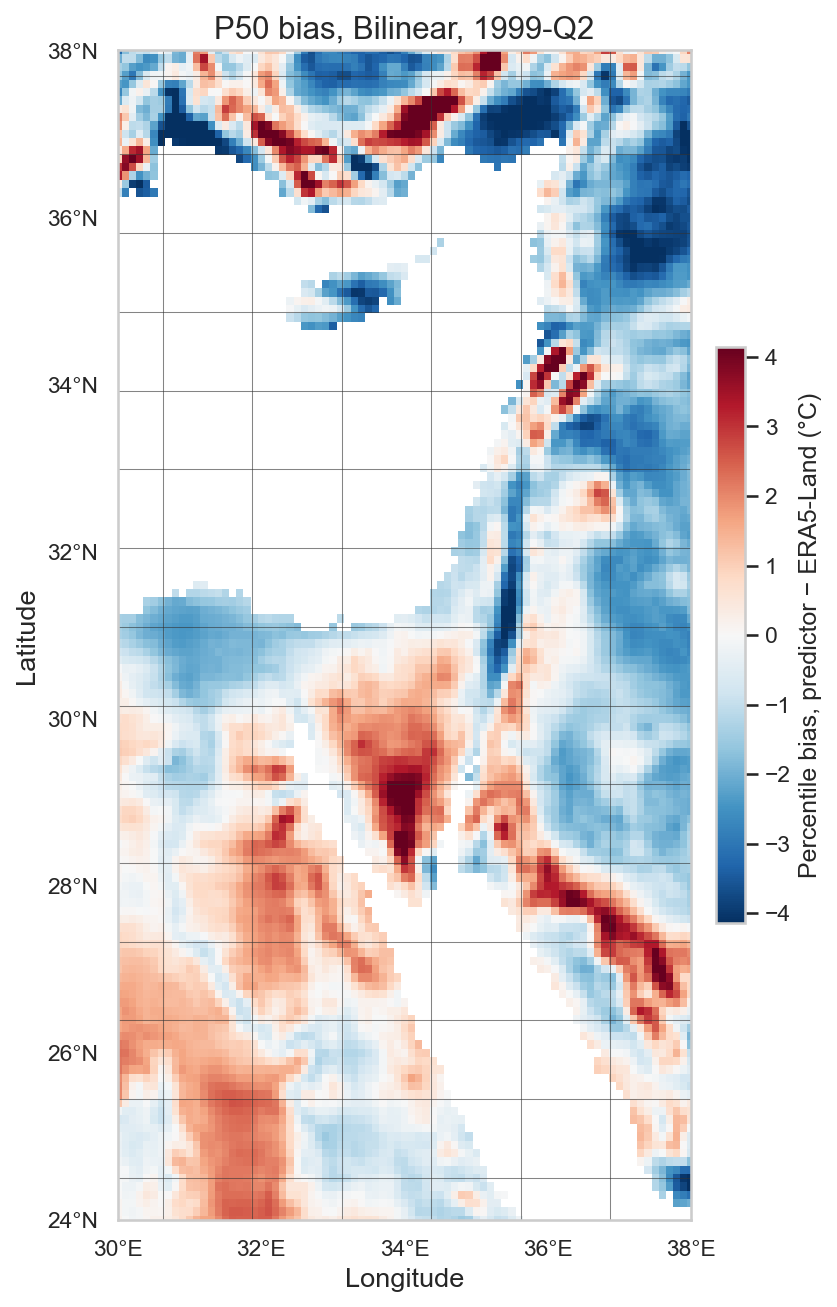

In [9]:
fig = qviz.plot_bias_map(
    focus.groupby(["lat", "lon"], observed=True)["bias"].mean()
         .reset_index().rename(columns={"bias": "mean_bias"}),
    era5_lats, era5_lons, region=REGION,
    coarse_lats=cmip_lats, coarse_lons=cmip_lons,
    title=(f"P{FOCUS_Q} bias, {qviz.PREDICTOR_LABELS[FOCUS_PREDICTOR]}, "
           f"{FOCUS_WINDOW}"),
    save_path=PLOT_DIR / "fig_q03_focus_bias_map.png",
)
plt.show()

**Fig. 3.** Spatial pattern of the median bias for the same slice. Colour is
predictor minus observation (°C), on a symmetric scale; CMIP6 cell boundaries
are overlaid. Data: bilinear predictor, P50, April–June 1999, EMME domain.

## 4. All five percentiles in the same slice

Holding the window and the predictor fixed, the five percentiles show whether
the bias depends on where in the distribution it is measured.

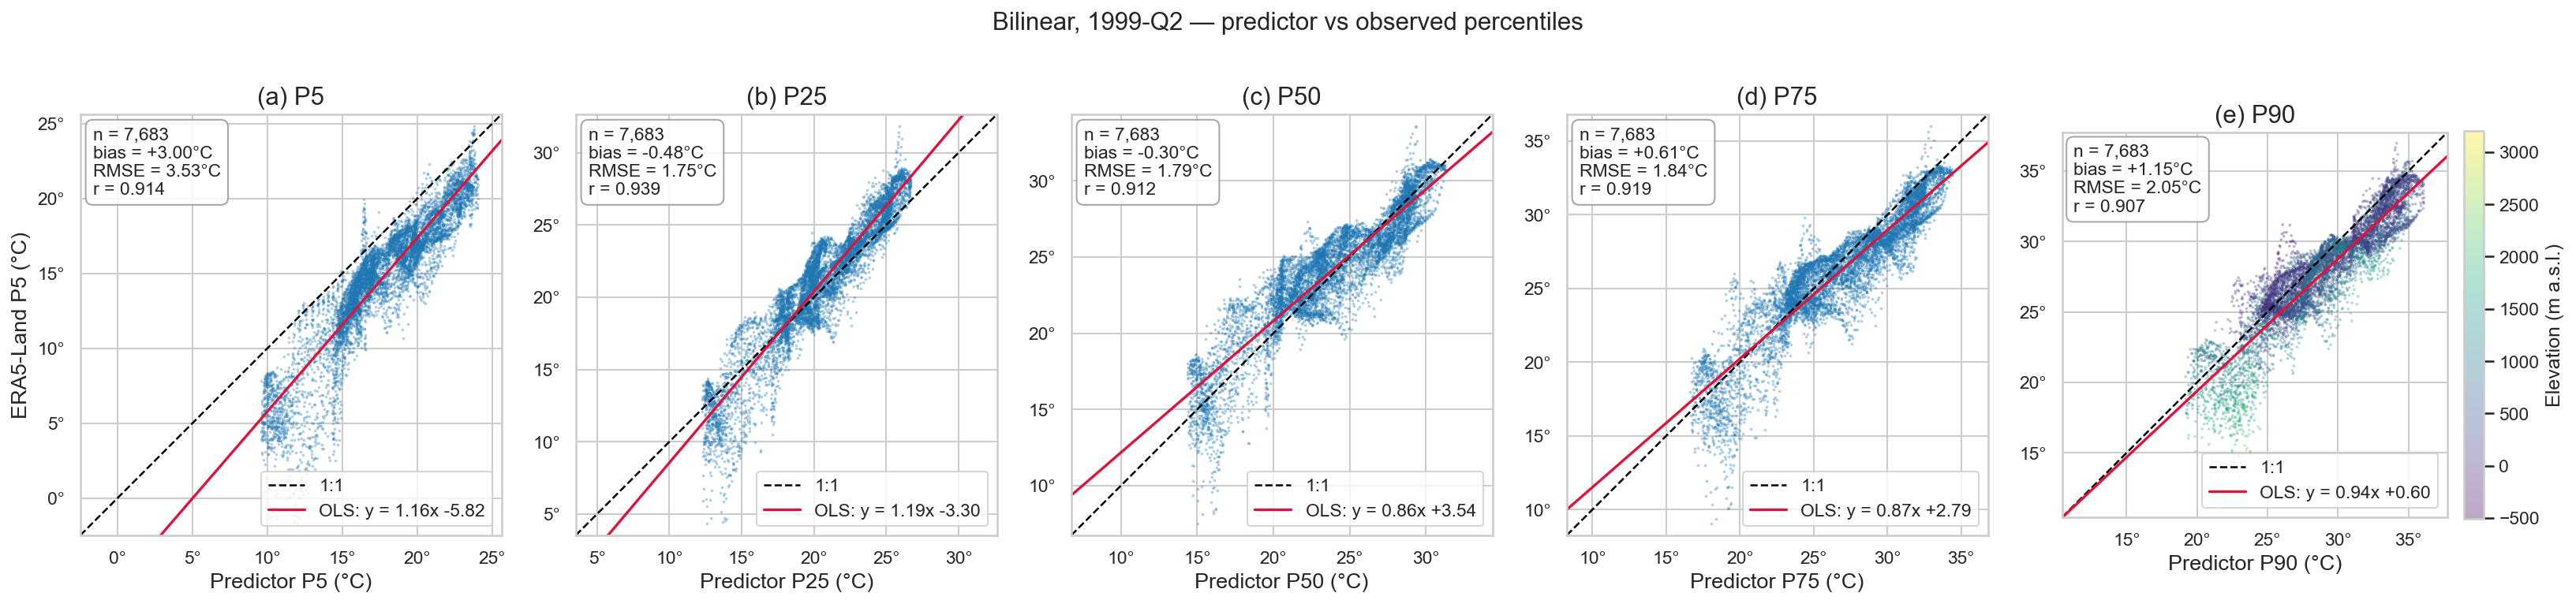

In [10]:
focus_wide = qmm.load_pct_table(QM_DIR, FOCUS_PREDICTOR, FOCUS_SCHEME)
focus_wide = focus_wide[focus_wide.window_label.astype(str) == FOCUS_WINDOW]

fig = qviz.plot_percentile_panels(
    focus_wide, percentiles=qw.PERCENTILES,
    suptitle=(f"{qviz.PREDICTOR_LABELS[FOCUS_PREDICTOR]}, {FOCUS_WINDOW} — "
              f"predictor vs observed percentiles"),
    save_path=PLOT_DIR / "fig_q04_focus_percentiles.png",
)
plt.show()

**Fig. 4.** Predictor percentile against observed percentile for the five
percentiles of interest, April–June 1999, bilinear predictor. Panels (a)–(e):
P5, P25, P50, P75, P90. Each point is one land pixel; the dashed line is 1:1 and
the red line the OLS fit. Points in panel (e) are coloured by elevation. Data:
ERA5-Land 2 m temperature and bilinearly regridded CMIP6 CESM2-WACCM TAS, EMME
domain.

In [11]:
rows = []
for q in qw.PERCENTILES:
    d = focus_wide[f"x_p{q}"].to_numpy() - focus_wide[f"y_p{q}"].to_numpy()
    m = qmm.combination_metrics(focus_wide[f"y_p{q}"].to_numpy(),
                                focus_wide[f"x_p{q}"].to_numpy())
    rows.append({"Percentile": f"P{q}", "Bias": m["bias"], "Std Dev": m["bias_sd"],
                 "MAE": m["mae"], "RMSE": m["rmse"], "Pearson r": m["pearson_r"],
                 "OLS slope": m["ols_slope"]})
print(f"{FOCUS_WINDOW}, {qviz.PREDICTOR_LABELS[FOCUS_PREDICTOR]} — "
      f"metrics by percentile (°C except r and slope)")
display(pd.DataFrame(rows).set_index("Percentile").round(3))

1999-Q2, Bilinear — metrics by percentile (°C except r and slope)


,Bias,Std Dev,MAE,RMSE,Pearson r,OLS slope
Percentile,,,,,,
P5,3.000,1.861,3.026,3.530,0.914,1.160
P25,-0.483,1.686,1.381,1.753,0.939,1.185
P50,-0.299,1.761,1.423,1.786,0.912,0.863
P75,0.614,1.736,1.437,1.842,0.919,0.872
P90,1.147,1.696,1.559,2.047,0.907,0.939


**Table 2.** Skill of the bilinear predictor by percentile for April–June 1999.
Bias is predictor minus observation. The OLS slope is from regressing observed
on predictor: a slope below 1 means the predictor's spread across pixels is too
wide. Data: EMME domain land pixels, n ≈ 7,700 per row.

## 5. Across predictors: the leaderboard

The full grid, scored over every window instance rather than a single one.
MAE is the headline number: it penalises a bias in either direction and is not
dominated by a few extreme pixels the way RMSE is.

In [12]:
board = (
    metrics[(metrics.scheme == FOCUS_SCHEME) & (metrics.percentile == FOCUS_Q)]
    .assign(Predictor=lambda d: d.predictor.map(qviz.PREDICTOR_LABELS))
    .sort_values("mae")
    [["Predictor", "bias", "bias_sd", "mae", "rmse", "pearson_r", "r2",
      "ols_slope", "ols_intercept", "n"]]
    .rename(columns={"bias": "Bias", "bias_sd": "Std Dev", "mae": "MAE",
                     "rmse": "RMSE", "pearson_r": "Pearson r", "r2": "R²",
                     "ols_slope": "OLS slope", "ols_intercept": "OLS intercept",
                     "n": "n"})
    .set_index("Predictor")
)
print(f"All {qviz.SCHEME_LABELS[FOCUS_SCHEME]} windows, P{FOCUS_Q} — "
      f"ranked by MAE (°C except r, R², slope)")
display(board.round(3))

All 1 quarter windows, P50 — ranked by MAE (°C except r, R², slope)


,Bias,Std Dev,MAE,RMSE,Pearson r,R²,OLS slope,OLS intercept,n
Predictor,,,,,,,,,
Trilinear (fitted Γ),1.020,1.948,1.754,2.198,0.969,0.923,1.017,-1.368,307320
Trilinear (−6.5 K/km),0.669,2.224,1.796,2.323,0.960,0.914,0.972,-0.107,307320
Bilinear,1.336,2.251,2.015,2.617,0.959,0.891,1.018,-1.711,307320
"k-NN, k=4",1.353,2.310,2.046,2.677,0.957,0.886,1.024,-1.854,307320
"k-NN, k=9",1.446,2.405,2.132,2.806,0.954,0.874,1.050,-2.480,307320


**Table 3.** Predictor skill over all 40 quarterly windows at P50, ranked by
mean absolute error. Bias is predictor minus observation. R² measures the
predictor used as is, with no correction fitted. Data: ERA5-Land and CMIP6
CESM2-WACCM, 1990–1999, EMME domain land pixels.

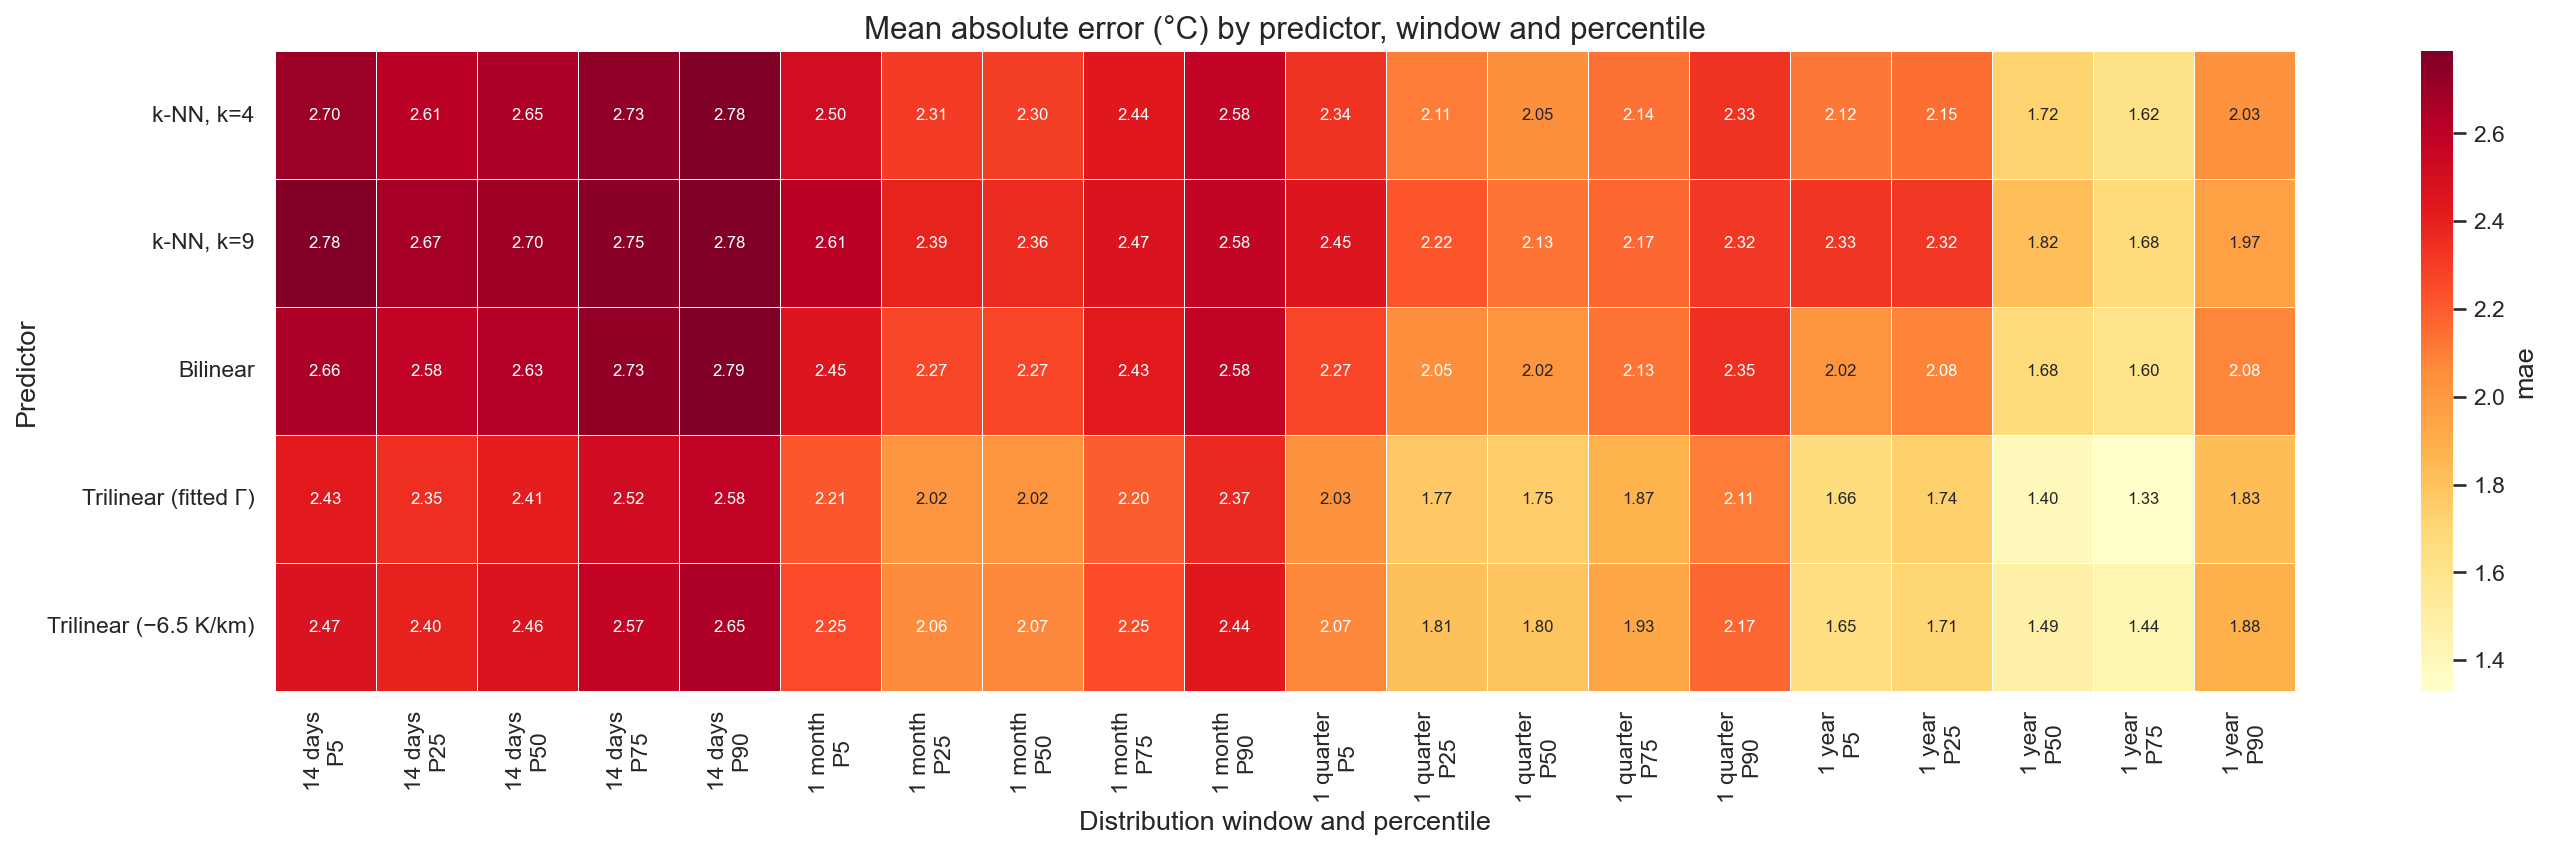

In [13]:
fig = qviz.plot_metric_heatmap(
    metrics, metric="mae",
    title="Mean absolute error (°C) by predictor, window and percentile",
    save_path=PLOT_DIR / "fig_q05_mae_heatmap.png",
)
plt.show()

**Fig. 5.** Mean absolute error of the percentile prediction for all 100
combinations. Rows are predictors, columns are the distribution window crossed
with the percentile. Darker means a larger error. Data: ERA5-Land and CMIP6
CESM2-WACCM, 1990–1999, EMME domain land pixels.

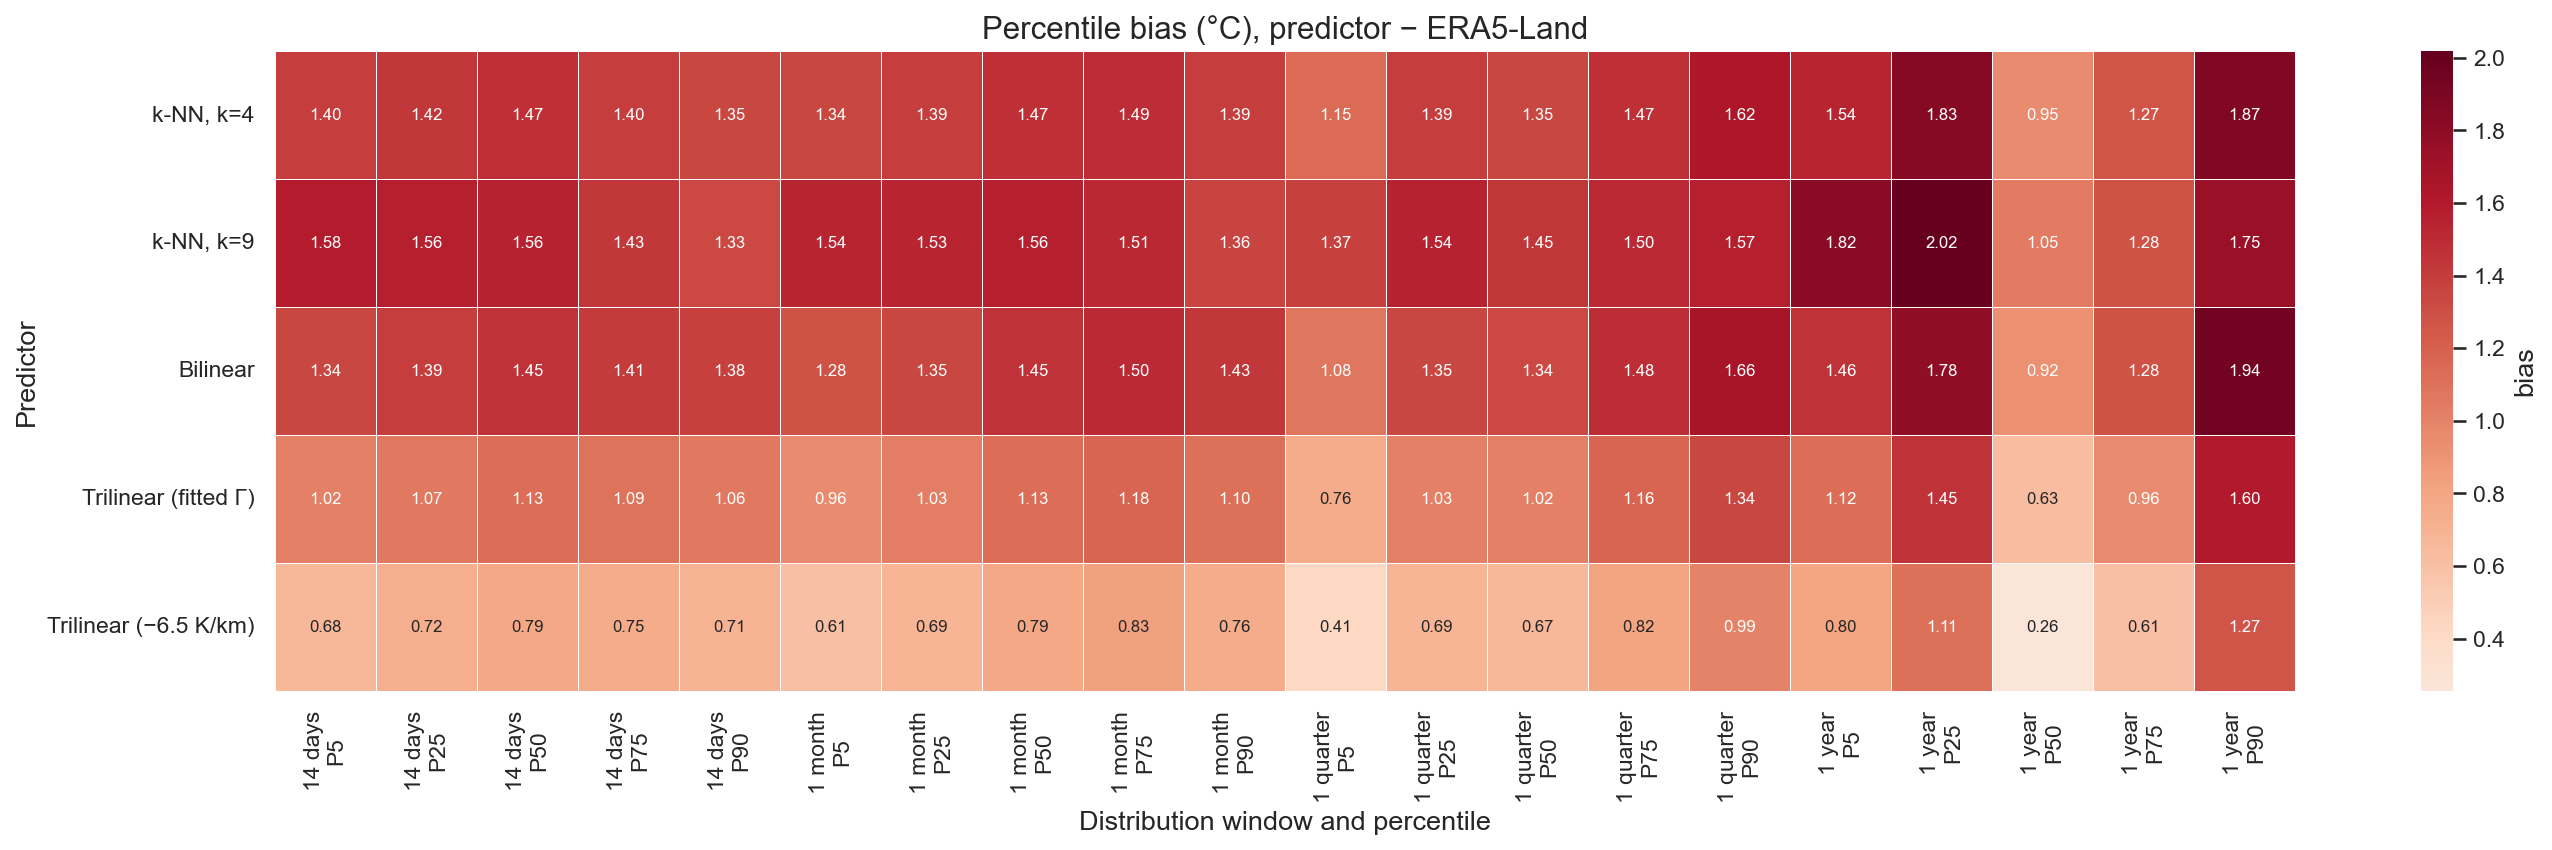

In [14]:
fig = qviz.plot_metric_heatmap(
    metrics, metric="bias",
    title="Percentile bias (°C), predictor − ERA5-Land",
    save_path=PLOT_DIR / "fig_q06_bias_heatmap.png",
)
plt.show()

**Fig. 6.** Mean percentile bias for all 100 combinations, on a diverging scale
centred at zero. Red means the predictor is too warm, blue too cold. Rows are
predictors, columns are window crossed with percentile. Data: ERA5-Land and
CMIP6 CESM2-WACCM, 1990–1999, EMME domain land pixels.

In [15]:
print("Mean MAE by predictor, averaged over all windows and percentiles (°C)")
display(
    metrics.groupby("predictor")[["bias", "mae", "rmse", "pearson_r", "r2"]]
    .mean()
    .reindex(PREDICTOR_NAMES)
    .rename(index=qviz.PREDICTOR_LABELS)
    .rename(columns={"bias": "Bias", "mae": "MAE", "rmse": "RMSE",
                     "pearson_r": "Pearson r", "r2": "R²"})
    .round(3)
)

print("\nMean MAE by percentile, averaged over predictors and windows (°C)")
display(
    metrics.groupby("percentile")[["bias", "mae"]].mean()
    .rename(columns={"bias": "Bias", "mae": "MAE"}).round(3)
)

Mean MAE by predictor, averaged over all windows and percentiles (°C)


,Bias,MAE,RMSE,Pearson r,R²
predictor,,,,,
"k-NN, k=4",1.427,2.309,3.059,0.922,0.789
"k-NN, k=9",1.516,2.374,3.165,0.917,0.775
Bilinear,1.415,2.283,3.011,0.925,0.795
Trilinear (fitted Γ),1.092,2.031,2.631,0.942,0.848
Trilinear (−6.5 K/km),0.748,2.078,2.732,0.928,0.833



Mean MAE by percentile, averaged over predictors and windows (°C)


,Bias,MAE
percentile,,
5,1.163,2.301
25,1.318,2.180
50,1.121,2.087
75,1.221,2.150
90,1.374,2.359


**Table 4.** Skill averaged across the grid. Upper block: by predictor, over all
four windows and five percentiles. Lower block: by percentile, over all
predictors and windows. Data: 1990–1999, EMME domain land pixels.

## 6. Across window lengths

A longer window gives a better-sampled distribution but averages over more
weather. This section asks which effect dominates.

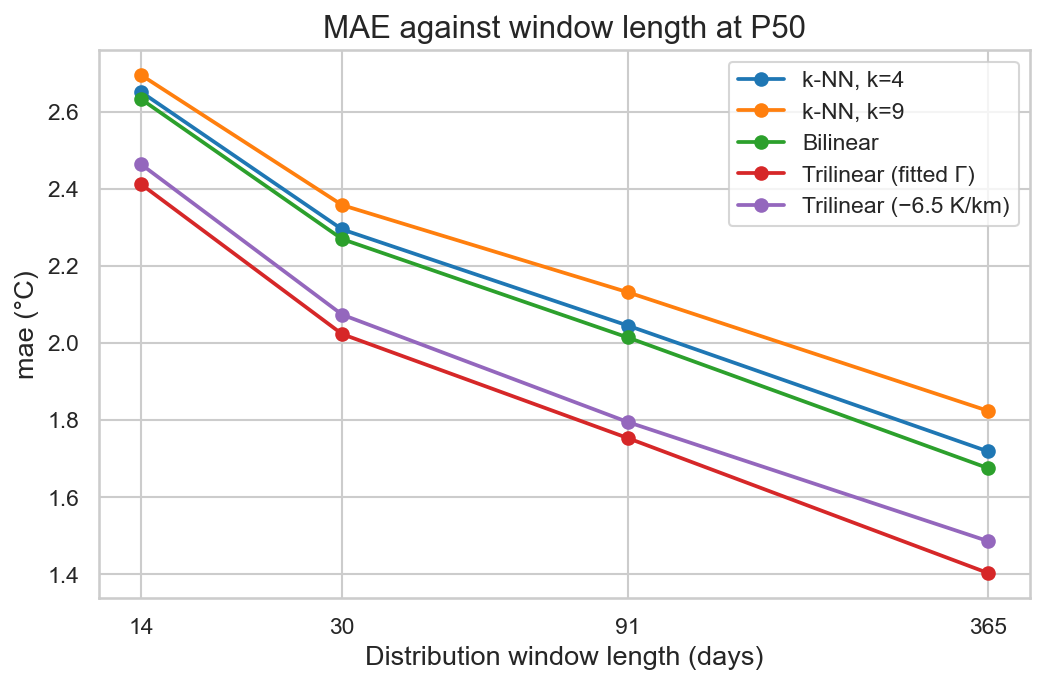

In [16]:
fig = qviz.plot_metric_by_window_length(
    metrics, metric="mae", percentile=FOCUS_Q,
    title=f"MAE against window length at P{FOCUS_Q}",
    save_path=PLOT_DIR / "fig_q07_mae_by_window.png",
)
plt.show()

**Fig. 7.** Mean absolute error of the median prediction against the length of
the distribution window, one line per predictor. The x-axis is the mean number
of days per window on a log scale, so the four schemes sit at their true
lengths. Data: ERA5-Land and CMIP6 CESM2-WACCM, 1990–1999, EMME domain land
pixels.

In [17]:
pivot_mae = (
    metrics.pivot_table(index="scheme", columns="percentile", values="mae")
    .reindex(qw.SCHEMES)
    .rename(index=qviz.SCHEME_LABELS)
)
pivot_mae.columns = [f"P{c}" for c in pivot_mae.columns]
print("MAE (°C) by window and percentile, averaged over the five predictors")
display(pivot_mae.round(3))

pivot_sd = (
    metrics.pivot_table(index="scheme", columns="percentile", values="bias_sd")
    .reindex(qw.SCHEMES)
    .rename(index=qviz.SCHEME_LABELS)
)
pivot_sd.columns = [f"P{c}" for c in pivot_sd.columns]
print("\nSD of the bias (°C) — the spread the correction would have to absorb")
display(pivot_sd.round(3))

MAE (°C) by window and percentile, averaged over the five predictors


,P5,P25,P50,P75,P90
scheme,,,,,
14 days,2.607,2.521,2.571,2.660,2.717
1 month,2.406,2.209,2.204,2.358,2.508
1 quarter,2.233,1.993,1.949,2.048,2.255
1 year,1.957,1.998,1.622,1.532,1.957



SD of the bias (°C) — the spread the correction would have to absorb


,P5,P25,P50,P75,P90
scheme,,,,,
14 days,3.245,3.103,3.119,3.234,3.303
1 month,3.061,2.686,2.575,2.729,2.989
1 quarter,2.828,2.364,2.227,2.300,2.504
1 year,2.420,2.025,2.050,1.727,1.792


**Table 5.** Upper block: mean absolute error by window length and percentile,
averaged over the five predictors. Lower block: standard deviation of the bias
across all (window, pixel) pairs, which is the part of the error a single
constant correction cannot remove. Data: 1990–1999, EMME domain land pixels.

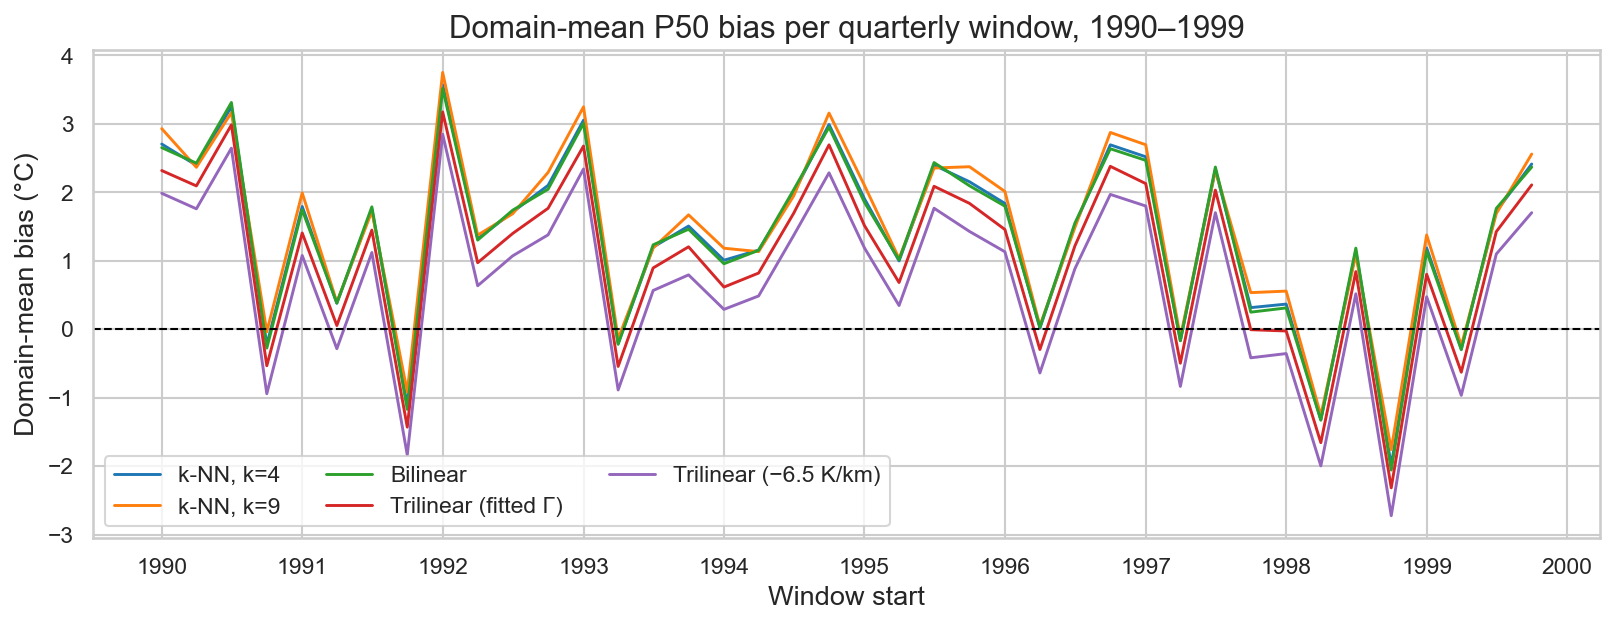

In [18]:
fig = qviz.plot_bias_by_window(
    window_bias, scheme=FOCUS_SCHEME, percentile=FOCUS_Q,
    title=f"Domain-mean P{FOCUS_Q} bias per quarterly window, 1990–1999",
    save_path=PLOT_DIR / "fig_q08_bias_timeseries.png",
)
plt.show()

**Fig. 8.** Domain-mean median bias for each quarterly window, one line per
predictor. The dashed line marks zero bias. Data: ERA5-Land and CMIP6
CESM2-WACCM, 1990–1999, EMME domain land pixels.

In [19]:
season_of_q = {1: "Q1 (JFM)", 2: "Q2 (AMJ)", 3: "Q3 (JAS)", 4: "Q4 (OND)"}
seasonal = (
    window_bias[(window_bias.scheme == "quarter")
                & (window_bias.percentile == FOCUS_Q)]
    .assign(quarter=lambda d: pd.to_datetime(d.window_start).dt.quarter
                               .map(season_of_q))
    .pivot_table(index="predictor", columns="quarter", values="mean_bias")
    .reindex(PREDICTOR_NAMES)
    .rename(index=qviz.PREDICTOR_LABELS)
)
print(f"Domain-mean P{FOCUS_Q} bias (°C) by calendar quarter, 1990–1999")
display(seasonal.round(2))

Domain-mean P50 bias (°C) by calendar quarter, 1990–1999


quarter,Q1 (JFM),Q2 (AMJ),Q3 (JAS),Q4 (OND)
predictor,,,,
"k-NN, k=4",1.99,0.43,1.90,1.08
"k-NN, k=9",2.18,0.46,1.87,1.28
Bilinear,1.94,0.43,1.94,1.03
Trilinear (fitted Γ),1.61,0.10,1.60,0.77
Trilinear (−6.5 K/km),1.28,-0.24,1.27,0.36


**Table 6.** Domain-mean median bias by calendar quarter and predictor,
averaged over the ten years. Positive means the predictor is too warm. Data:
1990–1999, EMME domain land pixels.

## 7. Where the predictors break down

Two structural features of the coarse grid are candidates for the residual
pattern: terrain the coarse cell smooths away, and coarse cells that mix land
with sea.

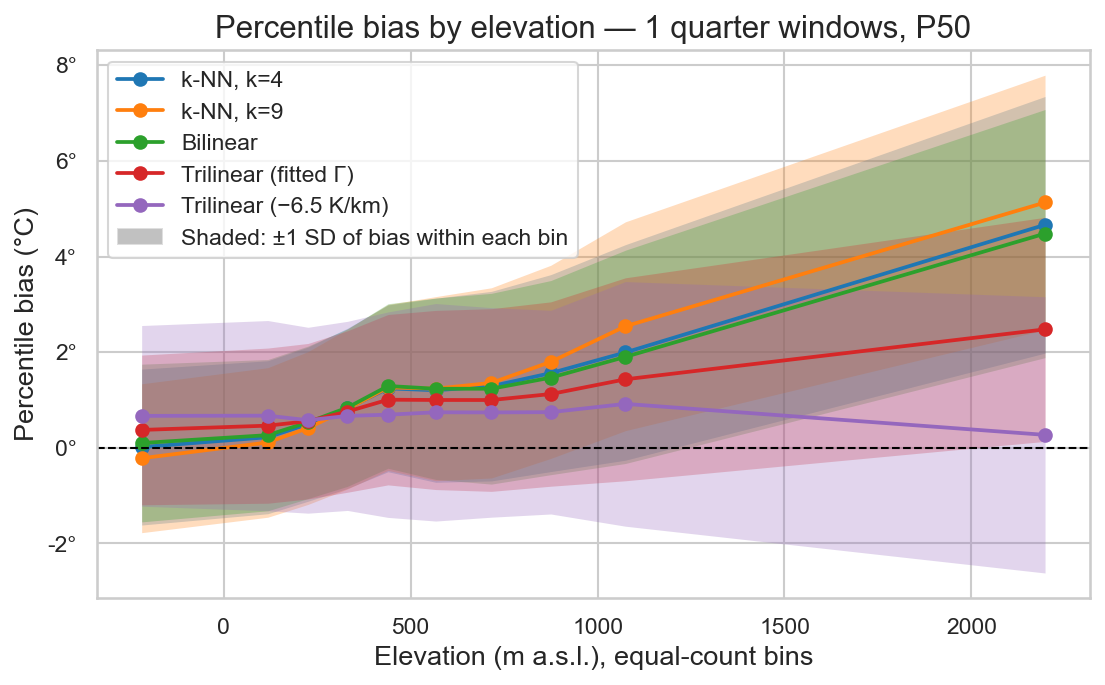

In [20]:
fig = qviz.plot_bias_vs_elevation(
    elev_bias, scheme=FOCUS_SCHEME, percentile=FOCUS_Q,
    save_path=PLOT_DIR / "fig_q09_bias_vs_elevation.png",
)
plt.show()

**Fig. 9.** Mean median bias against terrain elevation, one line per predictor.
Bins hold equal pixel counts, so their spacing reflects the domain's skew
toward low ground. The shaded band is ±1 SD of the bias within each bin. Data:
quarterly windows, P50, 1990–1999, EMME domain land pixels.

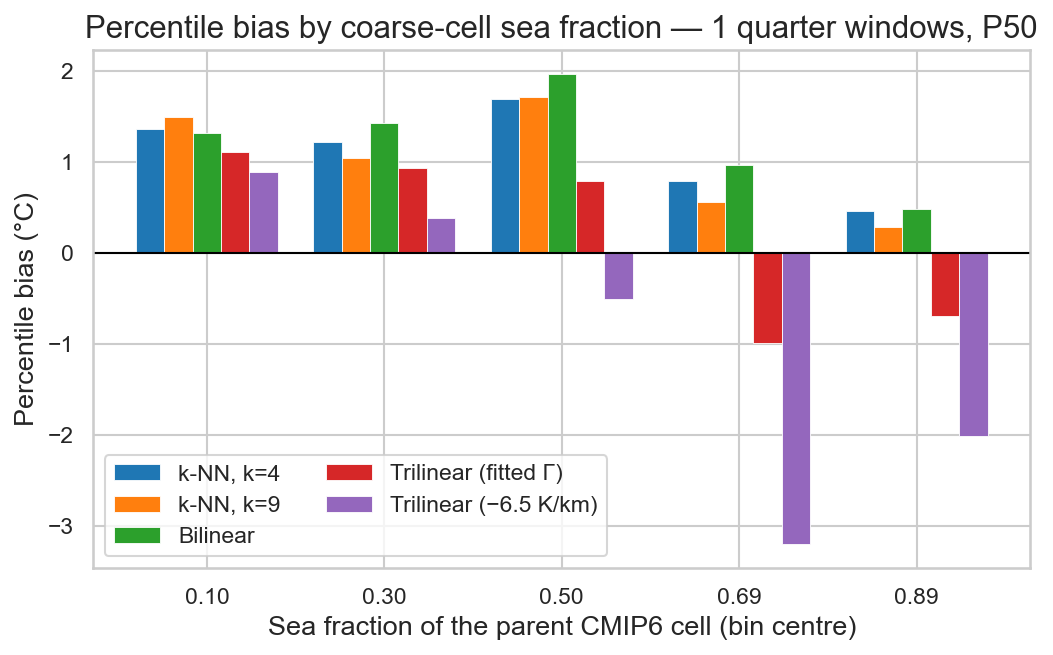

In [21]:
fig = qviz.plot_bias_by_sea_fraction(
    sea_bias, scheme=FOCUS_SCHEME, percentile=FOCUS_Q,
    save_path=PLOT_DIR / "fig_q10_bias_by_sea_fraction.png",
)
plt.show()

**Fig. 10.** Mean median bias grouped by the sea fraction of the parent CMIP6
cell, one bar per predictor within each bin. A sea fraction near zero marks an
inland cell; near one marks a cell almost entirely over water whose few land
pixels sit on the coast. Data: quarterly windows, P50, 1990–1999, EMME domain
land pixels.

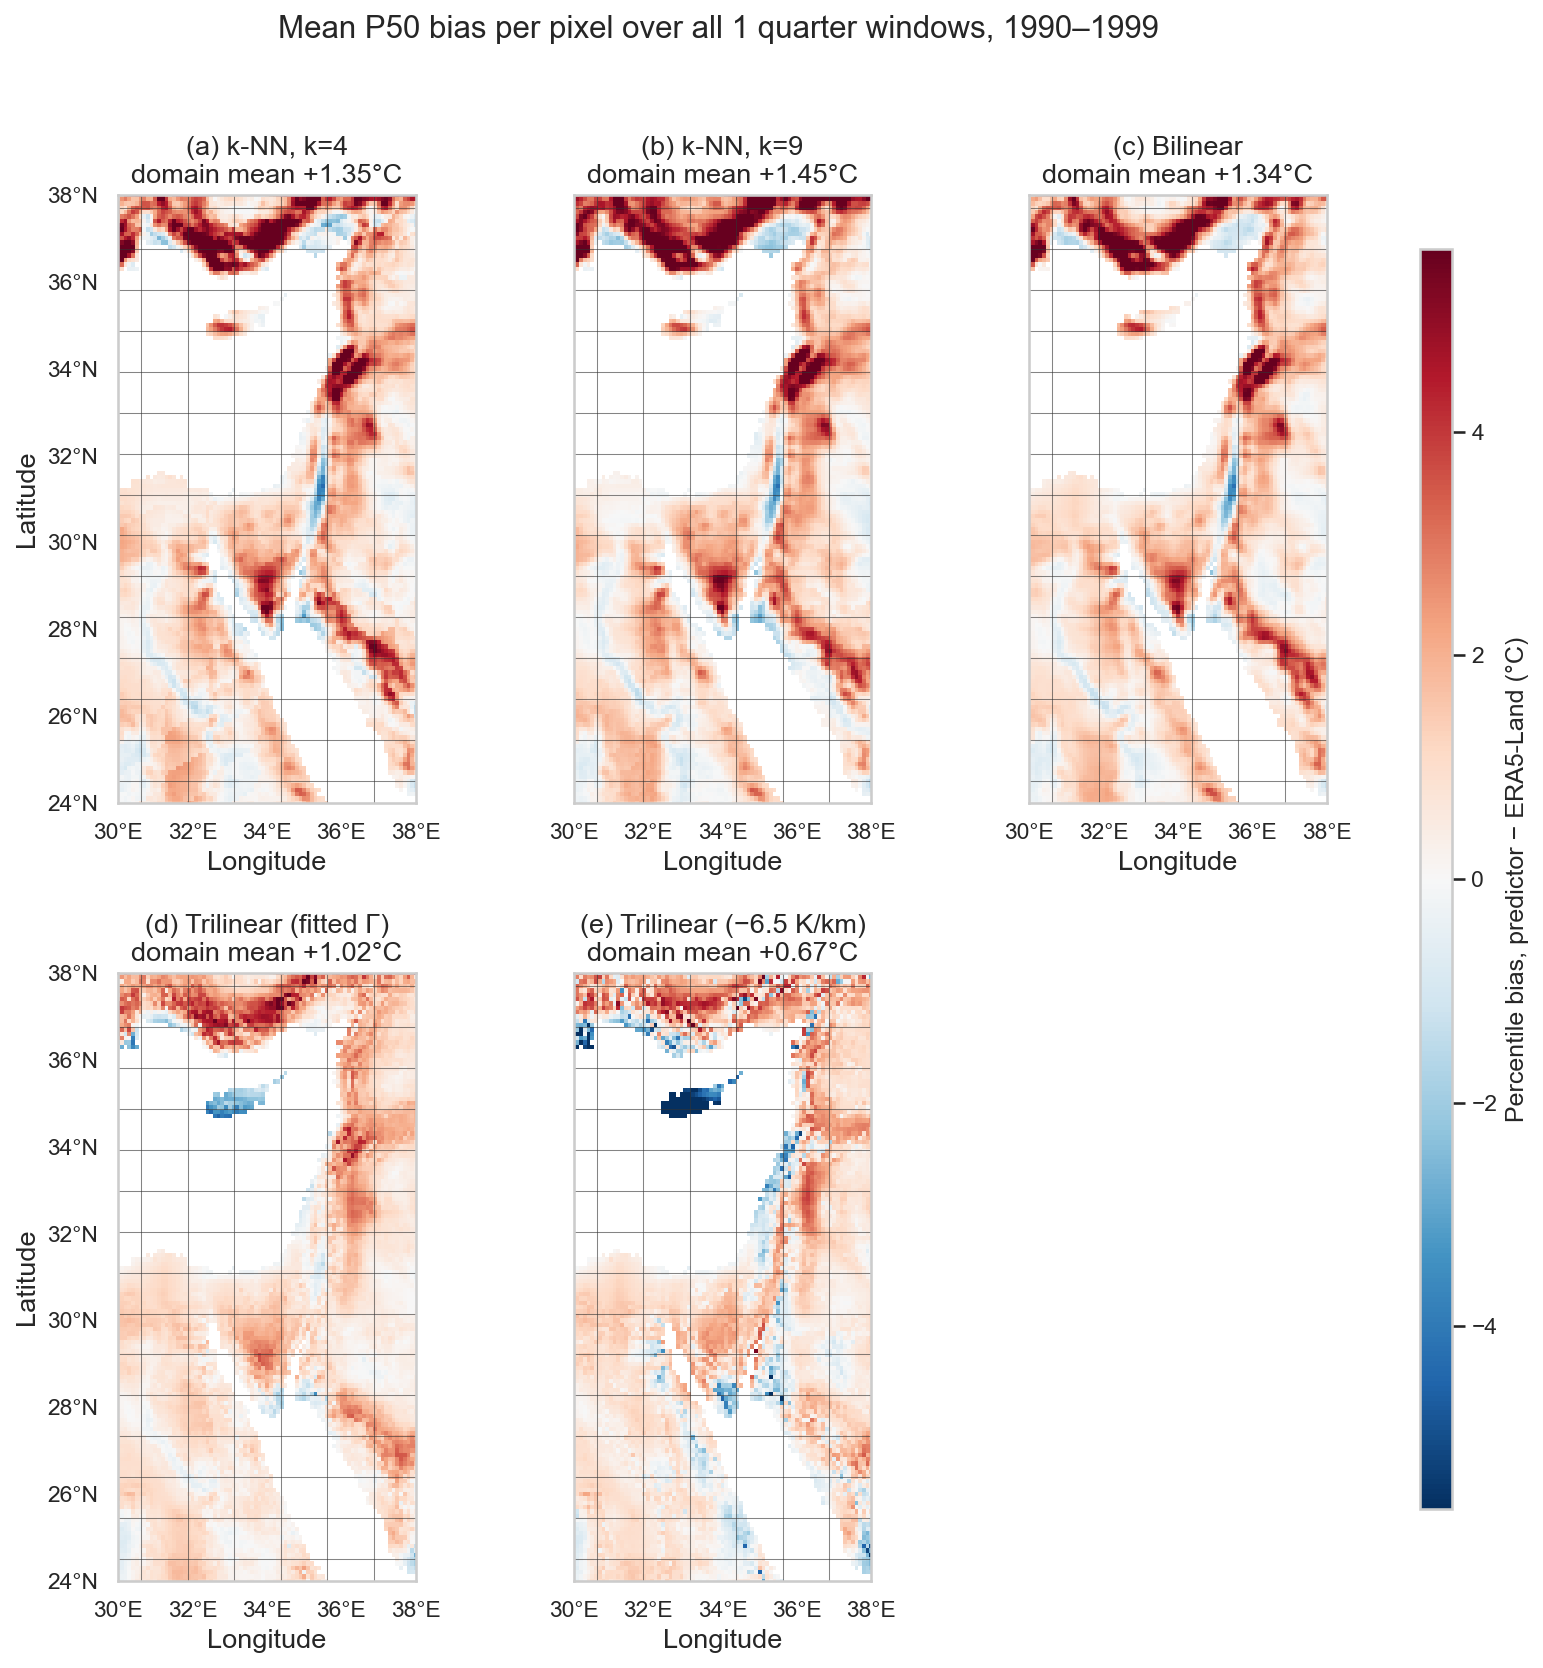

In [22]:
fig = qviz.plot_bias_map_grid(
    pixel_bias, era5_lats, era5_lons,
    predictors=PREDICTOR_NAMES, scheme=FOCUS_SCHEME, percentile=FOCUS_Q,
    region=REGION, ncols=3,
    suptitle=(f"Mean P{FOCUS_Q} bias per pixel over all "
              f"{qviz.SCHEME_LABELS[FOCUS_SCHEME]} windows, 1990–1999"),
    coarse_lats=cmip_lats, coarse_lons=cmip_lons,
    save_path=PLOT_DIR / "fig_q11_bias_map_grid.png",
)
plt.show()

**Fig. 11.** Mean median bias per land pixel, averaged over all 40 quarterly
windows, for each predictor on a shared diverging scale. Panels (a)–(e):
k-NN k=4, k-NN k=9, bilinear, trilinear with fitted Γ, trilinear with
−6.5 °C/km. CMIP6 cell boundaries are overlaid. Data: ERA5-Land and CMIP6
CESM2-WACCM, 1990–1999, EMME domain.

In [23]:
corr_rows = []
for predictor in PREDICTOR_NAMES:
    part = (
        pixel_bias[(pixel_bias.predictor == predictor)
                   & (pixel_bias.scheme == FOCUS_SCHEME)
                   & (pixel_bias.percentile == FOCUS_Q)]
        .merge(static[["lat", "lon", "elevation", "dz", "sea_fraction"]],
               on=["lat", "lon"], how="left")
    )
    corr_rows.append({
        "Predictor": qviz.PREDICTOR_LABELS[predictor],
        "vs elevation": part.mean_bias.corr(part.elevation),
        "vs Δz": part.mean_bias.corr(part.dz),
        "vs sea fraction": part.mean_bias.corr(part.sea_fraction),
        "Bias SD across pixels": part.mean_bias.std(),
    })
print(f"Pearson r between the per-pixel P{FOCUS_Q} bias and static pixel "
      f"attributes ({qviz.SCHEME_LABELS[FOCUS_SCHEME]} windows)")
display(pd.DataFrame(corr_rows).set_index("Predictor").round(3))

Pearson r between the per-pixel P50 bias and static pixel attributes (1 quarter windows)


,vs elevation,vs Δz,vs sea fraction,Bias SD across pixels
Predictor,,,,
"k-NN, k=4",0.757,0.684,-0.028,1.657
"k-NN, k=9",0.820,0.615,-0.072,1.797
Bilinear,0.745,0.721,0.028,1.573
Trilinear (fitted Γ),0.523,0.076,-0.286,1.089
Trilinear (−6.5 K/km),-0.060,-0.704,-0.462,1.535


**Table 7.** Correlation of the per-pixel mean bias with terrain elevation, with
the sub-grid terrain height Δz, and with the sea fraction of the parent coarse
cell. The final column is the spatial spread of the bias, which a spatially
uniform correction would leave untouched. Data: quarterly windows, P50,
1990–1999, EMME domain land pixels.

## 8. Summary

In [24]:
best_overall = (
    metrics.groupby("predictor")["mae"].mean().idxmin()
)
worst_overall = (
    metrics.groupby("predictor")["mae"].mean().idxmax()
)
mae_by_pred = metrics.groupby("predictor")["mae"].mean()
bias_by_pred = metrics.groupby("predictor")["bias"].mean()
mae_by_scheme = metrics.groupby("scheme")["mae"].mean().reindex(qw.SCHEMES)
mae_by_q = metrics.groupby("percentile")["mae"].mean()

print("Best predictor by mean MAE :", qviz.PREDICTOR_LABELS[best_overall],
      f"({mae_by_pred[best_overall]:.3f} °C)")
print("Worst predictor by mean MAE:", qviz.PREDICTOR_LABELS[worst_overall],
      f"({mae_by_pred[worst_overall]:.3f} °C)")
print("\nMAE by window (°C):", {qviz.SCHEME_LABELS[k]: round(v, 3)
                                for k, v in mae_by_scheme.items()})
print("MAE by percentile (°C):", {f"P{k}": round(v, 3)
                                  for k, v in mae_by_q.items()})
print("\nMean bias by predictor (°C):", {qviz.PREDICTOR_LABELS[k]: round(v, 3)
                                         for k, v in bias_by_pred.items()})

Best predictor by mean MAE : Trilinear (fitted Γ) (2.031 °C)
Worst predictor by mean MAE: k-NN, k=9 (2.374 °C)

MAE by window (°C): {'14 days': 2.615, '1 month': 2.337, '1 quarter': 2.095, '1 year': 1.813}
MAE by percentile (°C): {'P5': 2.301, 'P25': 2.18, 'P50': 2.087, 'P75': 2.15, 'P90': 2.359}

Mean bias by predictor (°C): {'Bilinear': 1.415, 'k-NN, k=4': 1.427, 'k-NN, k=9': 1.516, 'Trilinear (fitted Γ)': 1.092, 'Trilinear (−6.5 K/km)': 0.748}


### What worked

*The elevation term is the one change that helps.* Trilinear with a fitted Γ has
the lowest mean absolute error at every window length: 2.46°C for 14-day
windows, 2.16°C monthly, 1.91°C quarterly and 1.59°C annually. It wins at every
percentile as well. Averaged over the whole grid its MAE is 2.03°C against
2.28°C for bilinear, a reduction of 11%. Its spatial spread of bias is the
smallest of the five, 1.09°C against 1.57°C for bilinear (Table 7), so it leaves
less structure behind for a later correction to absorb.

*Terrain is the dominant error.* For the three predictors without an elevation
term, the per-pixel median bias correlates with elevation at r ≈ 0.75–0.82 and
with the sub-grid terrain height Δz at r ≈ 0.62–0.72 (Table 7). The lowest
elevation bin carries almost no bias (+0.02 to +0.10°C) while the highest bin,
centred near 2,200 m, reaches +4.5 to +5.1°C (Fig. 9). Roughly 18% of the
domain's land pixels lie above 1,000 m, so this is not a marginal population.
Fitting Γ removes most of that signal: the correlation of the residual bias with
Δz falls from 0.72 to 0.08, and the top-bin bias halves to +2.5°C.

*Longer windows are better, without exception.* MAE falls monotonically from
14-day to annual windows for every predictor (Fig. 7, Table 5), and the standard
deviation of the bias falls with it, from about 3.1°C to 2.05°C at P50. The
sampling noise in a 14-value percentile therefore outweighs the temporal detail
that a short window buys. This also means the 14-day results should not be read
as evidence that the predictors are worse at short time scales; part of that
error is noise in the target itself.

*The OLS slope is close to one for trilinear with a fitted Γ*, at 1.004 against
1.019 for k-NN k=4 and 1.057 for k-NN k=9. The remaining error is close to a
pure offset, which is the easiest shape for a later correction to handle.

### What did not work

*Averaging more coarse cells makes things worse.* k-NN with k=9 is the weakest
predictor on every metric and at every window length (MAE 2.37°C), behind k=4
(2.31°C), which is in turn behind bilinear (2.28°C). The ranking is consistent,
so spatial smoothing of the coarse field is not helping here. This does not
contradict the analog results of Dorita and Anton, who used a 3×3 regional mean
to select a historical date for a station; the task here is different, and any
smoothing that removes the local gradient removes information the percentile
comparison needs.

*The fixed −6.5 °C/km lapse rate overcorrects.* It gives the lowest mean bias of
all five predictors (0.75°C against 1.09°C for the fitted Γ) and flattens the
elevation dependence almost completely, from +4.5°C to +0.27°C in the top bin
(Fig. 9). But it is not the better predictor. Its MAE is higher (2.08 against
2.03°C), its spatial spread of bias is larger (1.54 against 1.09°C), its
within-bin spread at high elevation is the worst of the five (SD 2.89°C), and
its OLS slope drops to 0.934. The correlation of its bias with Δz is −0.70, that
is, the sign has flipped: the correction is now too strong rather than too weak.
A plausible reading is that the fitted Γ of about −3 °C/km is the rate the
bilinear residual actually supports, and applying twice that value trades a
smaller mean error for a larger spread.

*Coastal cells are where the terrain correction breaks.* For the untreated
predictors the bias falls gently as the parent coarse cell becomes more sea,
from about +1.4°C inland to +0.5°C. The trilinear predictors move the other way
and turn strongly negative, reaching −0.99°C for the fitted Γ and −3.21°C for
the fixed Γ in the 0.69 sea-fraction bin (Fig. 10). The mechanism is visible in
Fig. 11: a coarse cell that is nearly all sea has a cell-mean orography near
zero, so Δz for a land pixel inside it equals the full local terrain height and
the correction is applied at full strength. Cyprus is the clearest case. Any
next step that keeps the terrain term should treat these cells separately.

*The tails are harder than the middle.* MAE is smallest at P50 for every
predictor and rises toward both ends, with P90 the worst (Table 4). The bias at
P90 exceeds the bias at P50 by about 0.3°C. A correction fitted on the median
would therefore under-correct the upper tail.

*No predictor is close to unbiased.* Every one is warm at every percentile and
every window length (Fig. 6), which is consistent with the 1–2°C warm bias in
TAS already reported for this domain. The bias is also strongly seasonal: at P50
on quarterly windows it is +1.9 to +2.2°C in JFM and JAS but only about +0.4°C
in AMJ (Table 6). A single constant offset cannot serve all four quarters.

### Where this leaves the baseline

The diagnostic separates the total error into three parts that behave
differently. A large seasonal offset, common to all predictors. A terrain-linked
component that a linear function of Δz removes most of. And a residual spread of
1 to 1.5°C across pixels that none of the five predictors removes, and that a
spatially uniform correction would leave untouched.

Trilinear with a fitted Γ on quarterly or annual windows is the strongest
starting point of the five. Its bias is close to a pure offset, its spatial
structure is the flattest, and the terrain signal has largely been taken out
before any correction is fitted.

Two things are worth checking before fitting a correction. The lapse rate is
currently one value per season for the whole domain; the residual correlation
with elevation is still 0.52, so a Γ that varies in space may be needed. And the
coastal cells identified above may need their own treatment rather than a single
domain-wide rule.

*Caveats.* All numbers come from a single GCM (CESM2-WACCM, r1i1p1f1) over a
single decade, and Γ was fitted on the same decade it is evaluated on, so the
fitted-Γ results are optimistic by an unknown amount. A 14-day window holds 14
values, so its P5 and P90 are noisy; the window-length comparison should be read
with that in mind.